# Scientific Data Processing

## Scientific Python for Engineers Workshop - Hour 2

**Author:** Dilip Kalagotla  
**Contact:** dilip.kalagotla@gmail.com

## Learning Objectives

- Load data from CSV files using Pandas
- Explore and clean datasets
- Perform numerical operations with NumPy
- Create publication-quality visualizations

---

## Part 1: Sample Experimental Data (Pandas Quick Intro)

In this first part of Hour 2, we will treat `sample_data.csv` as a small experimental dataset and use it to practice loading, exploring, and visualizing data with Pandas, NumPy, and Matplotlib.

## Part 2: LES Cylinder CFD Data (Simulation Example)

In the second part of this notebook, we will work with a subset of LES cylinder flow data using `lptlib`, and show how to load structured CFD results, make contour plots, and build simple animations of the flow field.

## Setup

First, let's import the libraries we'll need.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Optional: make plots look nicer
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## 1. Loading Data with Pandas

Pandas makes it easy to load data from various file formats:
- CSV: `pd.read_csv()`
- Excel: `pd.read_excel()`
- JSON: `pd.read_json()`
- And many more!

In [2]:
# Load the sample data
df = pd.read_csv('data/sample_data.csv')

# Display first few rows
print("First 5 rows:")
# one line here

First 5 rows:


In [3]:
# Display last few rows
print("Last 5 rows:")
# one line here

Last 5 rows:


---
## 2. Exploring the Data

In [4]:
# Basic info about the DataFrame
# shape of the df -- one line -- shape()

# columns names in the df -- one line -- columns


In [5]:
# Data types
print("Data types:")
# one line -- dtypes

Data types:


In [6]:
# Summary statistics
print("Summary statistics:")

# one line -- describe()

Summary statistics:


In [7]:
# Check for missing values
print("Missing values per column:")

# one line -- isnull() sum()
print(df.isnull().sum())

Missing values per column:
time           0
temperature    0
pressure       0
velocity_x     0
velocity_y     0
velocity_z     0
density        0
dtype: int64


---
## 3. Accessing Data

There are multiple ways to access data in a DataFrame.

In [8]:
# Access a single column (returns a Series)
# one line -- remove 0 and type df['temperatures']
temperatures = df['temperature']#0
print(f"Temperature column type: {type(temperatures)}")
print(temperatures.head())

Temperature column type: <class 'pandas.core.series.Series'>
0    300.0
1    301.2
2    302.5
3    303.8
4    305.1
Name: temperature, dtype: float64


In [9]:
# Access multiple columns (returns a DataFrame)
# one line -- df[['velocity_x', 'velocity_y', 'velocity_z']]
velocity_data = df[['velocity_x', 'velocity_y', 'velocity_z']]
velocity_data.head()

,velocity_x,velocity_y,velocity_z
0,10.5,0.0,0.0
1,10.8,0.5,0.1
2,11.2,1.0,0.2
3,11.5,1.5,0.3
4,11.9,2.0,0.4


In [10]:
# Access by row index using .iloc (integer location)
print("Row 5:")
# one line --- .iloc[5]

Row 5:


In [11]:
# Access by row and column
print(f"Temperature at row 5: {df.iloc[5]['temperature']}")
print(f"Or using loc: {df.loc[5, 'temperature']}")

Temperature at row 5: 306.4
Or using loc: 306.4


In [12]:
# Boolean indexing (filtering)
high_temp = df[df['temperature'] > 310]
print(f"Rows where temperature > 310K:")
high_temp

Rows where temperature > 310K:


,time,temperature,pressure,velocity_x,velocity_y,velocity_z,density
12,1.2,310.2,101265.0,13.6,3.8,1.1,1.206
13,1.3,310.5,101260.0,13.7,3.9,1.1,1.205
14,1.4,310.7,101255.0,13.8,4.0,1.2,1.204
15,1.5,311.0,101250.0,13.9,4.1,1.2,1.203
16,1.6,311.2,101245.0,14.0,4.2,1.3,1.202
17,1.7,311.4,101240.0,14.1,4.3,1.3,1.201
18,1.8,311.6,101235.0,14.2,4.4,1.4,1.200
19,1.9,311.8,101230.0,14.3,4.5,1.4,1.199
20,2.0,312.0,101225.0,14.4,4.6,1.5,1.198


---
## 4. Data Manipulation

In [13]:
# Create a new column: velocity magnitude
df['velocity_magnitude'] = np.sqrt(
    df['velocity_x']**2 + 
    df['velocity_y']**2 + 
    df['velocity_z']**2
)

print("Added velocity_magnitude column:")
df[['velocity_x', 'velocity_y', 'velocity_z', 'velocity_magnitude']].head()

Added velocity_magnitude column:


,velocity_x,velocity_y,velocity_z,velocity_magnitude
0,10.5,0.0,0.0,10.500000
1,10.8,0.5,0.1,10.812030
2,11.2,1.0,0.2,11.246333
3,11.5,1.5,0.3,11.601293
4,11.9,2.0,0.4,12.073525


In [14]:
# Convert temperature from Kelvin to Celsius
df['temperature_celsius'] = df['temperature'] - 273.15

print("Temperature comparison:")
df[['temperature', 'temperature_celsius']].head()

Temperature comparison:


,temperature,temperature_celsius
0,300.0,26.85
1,301.2,28.05
2,302.5,29.35
3,303.8,30.65
4,305.1,31.95


In [15]:
# Calculate dynamic pressure (0.5 * rho * V^2)
df['dynamic_pressure'] = 0.5 * df['density'] * df['velocity_magnitude']**2

print("Dynamic pressure:")
df[['density', 'velocity_magnitude', 'dynamic_pressure']].head()

Dynamic pressure:


,density,velocity_magnitude,dynamic_pressure
0,1.225,10.500000,67.528125
1,1.223,10.812030,71.484350
2,1.221,11.246333,77.216040
3,1.219,11.601293,82.032605
4,1.217,12.073525,88.701045


---
## 5. NumPy Operations

Pandas and NumPy work seamlessly together.

---
## 6. Visualization with Matplotlib

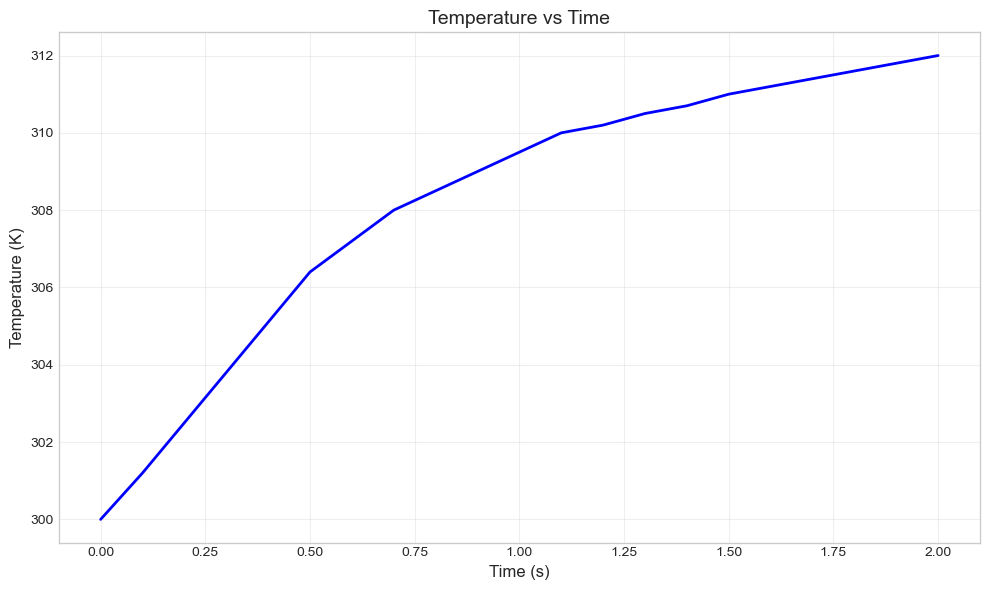

In [16]:
# Simple time series plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['time'], df['temperature'], 'b-', linewidth=2)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Temperature vs Time', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
fs = 14
fs2 = fs+2
fs3 = fs+4
# Setting plotting parameters
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rc('xtick',labelsize=fs)
plt.rc('ytick',labelsize=fs)


# Restore matplotlib defaults if desired
# plt.rcdefaults()

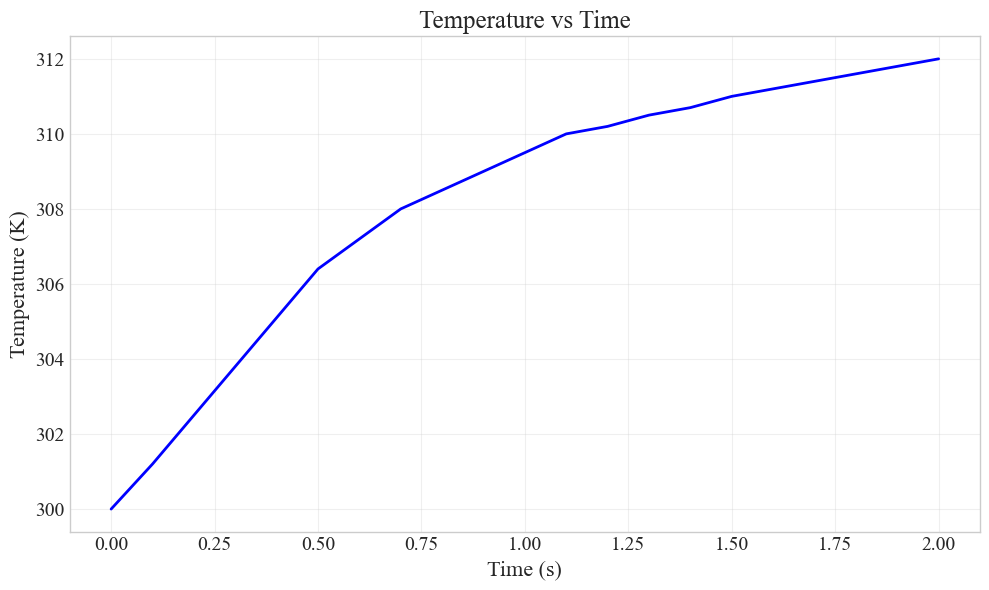

In [23]:
# Simple time series plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['time'], df['temperature'], 'b-', linewidth=2)
ax.set_xlabel('Time (s)', fontsize=fs2)
ax.set_ylabel('Temperature (K)', fontsize=fs2)
ax.set_title('Temperature vs Time', fontsize=fs3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

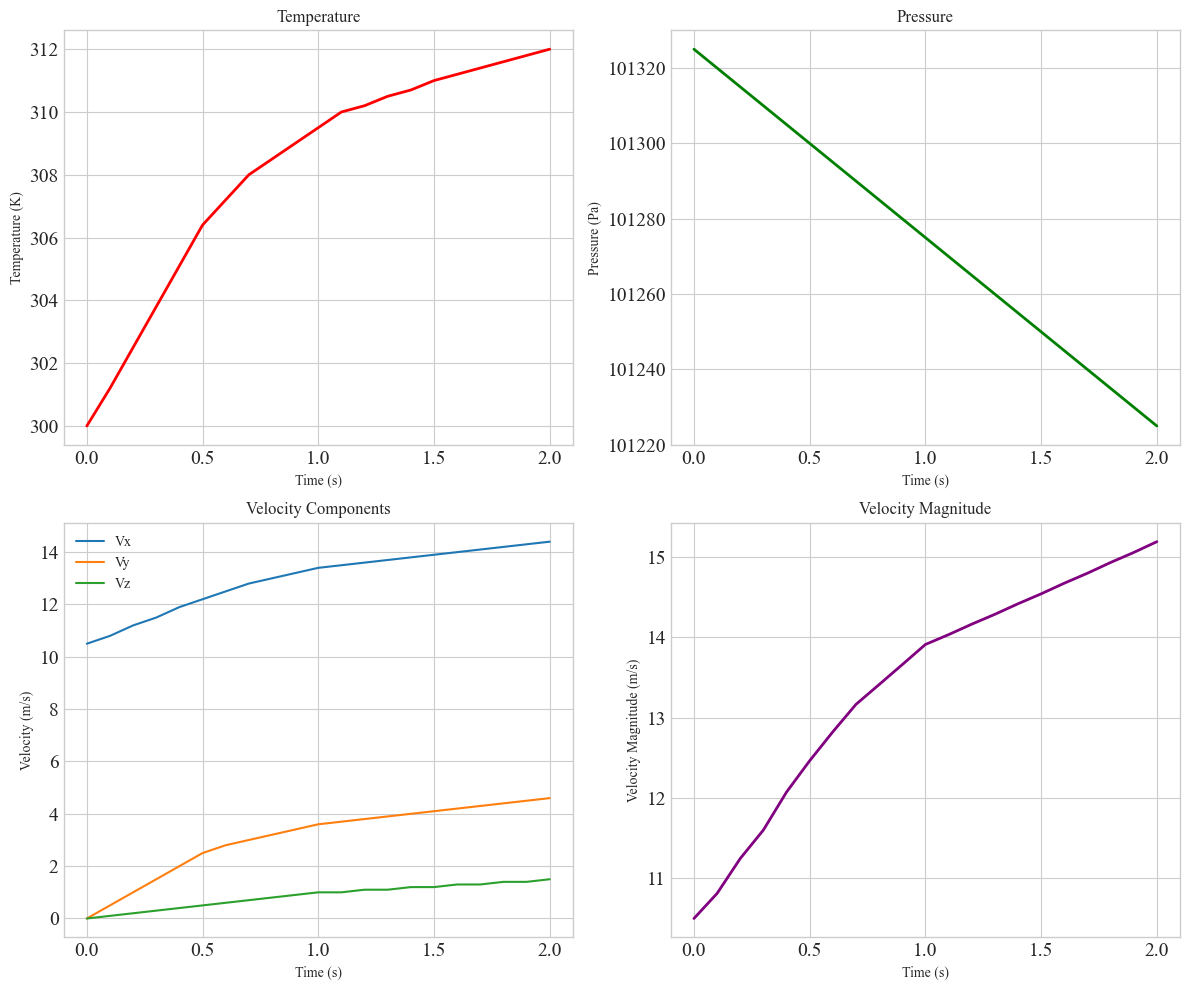

In [24]:
# Multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Temperature
axes[0, 0].plot(df['time'], df['temperature'], 'r-', linewidth=2)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Temperature (K)')
axes[0, 0].set_title('Temperature')

# Pressure
axes[0, 1].plot(df['time'], df['pressure'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Pressure (Pa)')
axes[0, 1].set_title('Pressure')

# Velocity components
axes[1, 0].plot(df['time'], df['velocity_x'], label='Vx')
axes[1, 0].plot(df['time'], df['velocity_y'], label='Vy')
axes[1, 0].plot(df['time'], df['velocity_z'], label='Vz')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Velocity (m/s)')
axes[1, 0].set_title('Velocity Components')
axes[1, 0].legend()

# Velocity magnitude
axes[1, 1].plot(df['time'], df['velocity_magnitude'], 'purple', linewidth=2)
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Velocity Magnitude (m/s)')
axes[1, 1].set_title('Velocity Magnitude')

plt.tight_layout()
plt.show()

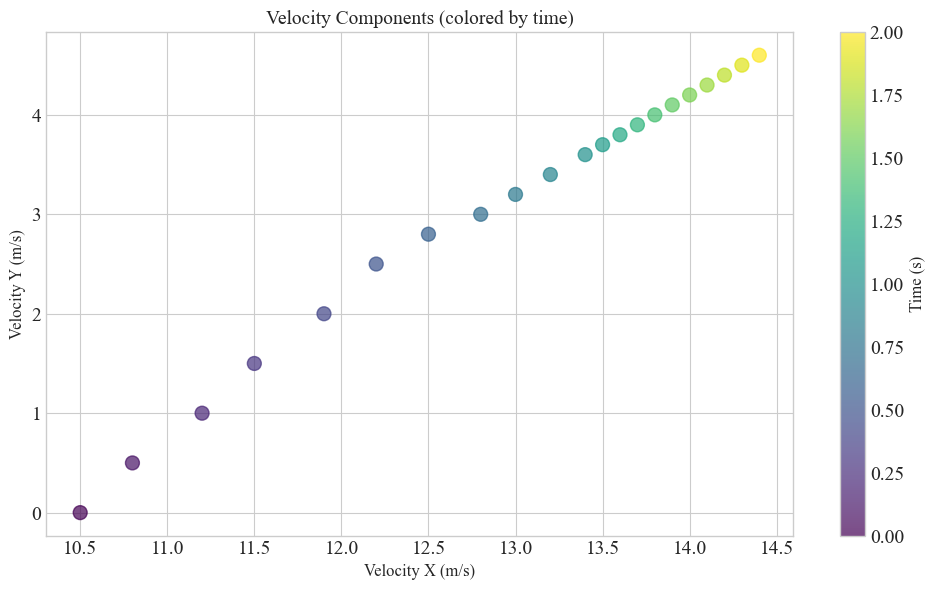

In [25]:
# Scatter plot with colorbar
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['velocity_x'], 
    df['velocity_y'], 
    c=df['time'], 
    cmap='viridis',
    s=100,
    alpha=0.7
)

ax.set_xlabel('Velocity X (m/s)', fontsize=12)
ax.set_ylabel('Velocity Y (m/s)', fontsize=12)
ax.set_title('Velocity Components (colored by time)', fontsize=14)

cbar = plt.colorbar(scatter)
cbar.set_label('Time (s)', fontsize=12)

plt.tight_layout()
plt.show()

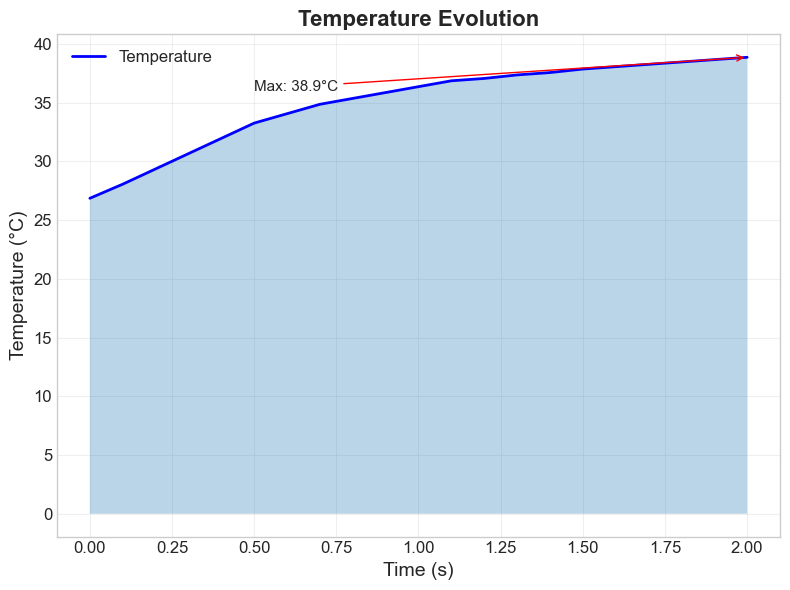

In [18]:
# Publication-quality figure
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(df['time'], df['temperature_celsius'], 'b-', linewidth=2, label='Temperature')
ax.fill_between(df['time'], df['temperature_celsius'], alpha=0.3)

ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Temperature (°C)', fontsize=14)
ax.set_title('Temperature Evolution', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Add annotations
max_idx = df['temperature_celsius'].idxmax()
ax.annotate(
    f'Max: {df.loc[max_idx, "temperature_celsius"]:.1f}°C',
    xy=(df.loc[max_idx, 'time'], df.loc[max_idx, 'temperature_celsius']),
    xytext=(0.5, 36),
    fontsize=11,
    arrowprops=dict(arrowstyle='->', color='red')
)

plt.tight_layout()

# Save the figure
# fig.savefig('temperature_plot.png', dpi=300, bbox_inches='tight')

plt.show()

In [19]:
# Convert DataFrame columns to NumPy arrays
time_array = df['time'].values
temp_array = df['temperature'].values

print(f"Type: {type(time_array)}")
print(f"Array shape: {time_array.shape}")

Type: <class 'numpy.ndarray'>
Array shape: (21,)


In [20]:
# NumPy statistical operations
print(f"Mean temperature: {np.mean(temp_array):.2f} K")
print(f"Std temperature: {np.std(temp_array):.2f} K")
print(f"Max temperature: {np.max(temp_array):.2f} K")
print(f"Min temperature: {np.min(temp_array):.2f} K")

Mean temperature: 308.17 K
Std temperature: 3.58 K
Max temperature: 312.00 K
Min temperature: 300.00 K


In [21]:
# Numerical differentiation (temperature rate of change)
dT_dt = np.gradient(temp_array, time_array)
df['dT_dt'] = dT_dt

print("Temperature rate of change (K/s):")
df[['time', 'temperature', 'dT_dt']].head(10)

Temperature rate of change (K/s):


,time,temperature,dT_dt
0,0.0,300.0,12.0
1,0.1,301.2,12.5
2,0.2,302.5,13.0
3,0.3,303.8,13.0
4,0.4,305.1,13.0
5,0.5,306.4,10.5
6,0.6,307.2,8.0
7,0.7,308.0,6.5
8,0.8,308.5,5.0
9,0.9,309.0,5.0


In [22]:
# Numerical integration (total impulse from velocity)
# Using trapezoidal rule
total_displacement_x = np.trapezoid(df['velocity_x'], df['time'])
print(f"Total X displacement: {total_displacement_x:.2f} m")

Total X displacement: 26.01 m


---
## Part 2: LES Cylinder CFD Data (Simulation Example)

In this second part, we switch from a small experimental-style CSV to a **large-eddy simulation (LES) cylinder flow** case.

We will:
- Load a precomputed LES grid (`cylinder.sp.x`) and a few flow snapshots (`sol-*.q`) using `lptlib`.
- Extract a 2D mid-plane and compute the streamwise velocity component \(u\).
- Visualize \(u(x, y)\) with a contour plot.
- (Optionally) animate how the velocity field evolves over time.

> **Note:** This section assumes you have a small subset of LES files in `hour2_scientific/data/cylinder/` (see that folder's `README.md`) and that `lptlib` is installed in your environment.

In [23]:
# Imports for LES cylinder data (Part 2)
try:
    # lptlib provides GridIO and FlowIO utilities for structured CFD data
    from lptlib.io.plot3dio import GridIO, FlowIO
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import sys
    import os

    # Optional: make plots look nicer
    plt.style.use('seaborn-v0_8-whitegrid')

    print("Libraries loaded successfully!")
    print("lptlib imported successfully.")
except ImportError:
    print("lptlib is not installed. To run the LES cylinder section, install it with e.g. `pip install lptlib` or your local lptlib source.")


lptlib is not installed. To run the LES cylinder section, install it with e.g. `pip install lptlib` or your local lptlib source.


In [24]:
# Import helper functions and animation utilities from modules
DATA_DIR = os.path.join("hour2_scientific", "data", "cylinder") if os.getcwd().endswith("dc-qc-sci-python") else os.path.join("data", "cylinder")

# Import helper functions and animation utilities
from modules.animation import animate_u_contours
from modules.helpers import prepare_midplane_u

print("Modules imported successfully!")


ModuleNotFoundError: No module named 'lptlib'

In [3]:
# Load grid and a single LES snapshot
# Grid and one example flow file (small subset shipped in hour2_scientific/data/cylinder)
grid_path = os.path.join(DATA_DIR, "cylinder.sp.x")
example_flow_path = os.path.join(DATA_DIR, "sol-0000010.q")

print("Grid path:", grid_path)
print("Example flow file:", example_flow_path)

if not os.path.exists(grid_path):
    raise FileNotFoundError(f"Grid file not found: {grid_path}.\nCheck that you've copied 'cylinder.sp.x' into data/cylinder/.")

if not os.path.exists(example_flow_path):
    raise FileNotFoundError(
        f"Example flow file not found: {example_flow_path}.\n"
        "Copy a few 'sol-*.q' files into data/cylinder/ as described in data/cylinder/README.md."
    )

# Read grid and flow
grid = GridIO(grid_path)
grid.read_grid()
flow = FlowIO(example_flow_path)
flow.read_flow(data_type="f4")

Grid path: data\cylinder\cylinder.sp.x
Example flow file: data\cylinder\sol-0000010.q
Grid data reading is successful for data\cylinder\cylinder.sp.x

Flow data reading is successful for data\cylinder\sol-0000010.q



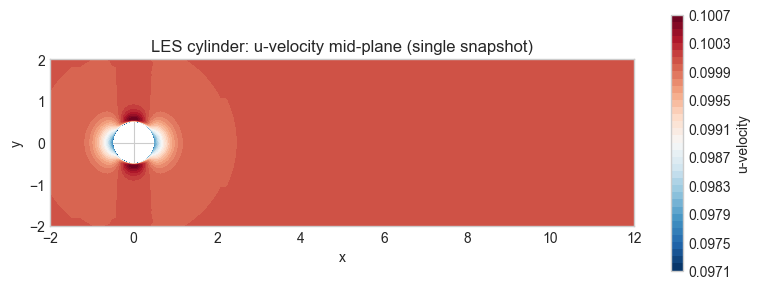

In [4]:
# Static contour plot of u-velocity on the mid-plane

fig, ax = plt.subplots(figsize=(8, 3))

blocks = prepare_midplane_u(grid, flow)
contours = []
for X, Y, U in blocks:
    cs = ax.contourf(X, Y, U, levels=40, cmap="RdBu_r")
    contours.append(cs)

cbar = fig.colorbar(contours[-1], ax=ax)
cbar.set_label("u-velocity")

# Match the zoom/axes from the original scripts (same as animation)
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 2)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("LES cylinder: u-velocity mid-plane (single snapshot)")

plt.tight_layout()
plt.show()

### Interactive Animation with Controls

The animation below will open in a **separate interactive window** with play/pause controls, step forward/backward buttons, and a slider to navigate through frames.

> **Note:** For the interactive window to appear, you may need to install a GUI backend:
> - Windows/Linux: Usually works with default `tkinter` (comes with Python)
> - If needed: `pip install PyQt5` for better performance
> - If the window doesn't appear, the animation will display inline instead

In [6]:
# Simple LES u-velocity animation over a few timesteps (interactive pop-out window)
%matplotlib qt
animate_u_contours(grid_path=grid_path, example_flow_path=example_flow_path,
                       interval_ms=80, levels=40, save_path=None)


# Display the animation (will open in separate window)
plt.show()

# Optional: save to mp4 if ffmpeg is available (commented out by default)
# anim.save("les_cylinder_u_animation.mp4", dpi=150, writer="ffmpeg")


Grid data reading is successful for data\cylinder\cylinder.sp.x

Flow data reading is successful for data\cylinder\sol-0000010.q

Flow data reading is successful for data\cylinder\sol-0000020.q

Flow data reading is successful for data\cylinder\sol-0000030.q

Flow data reading is successful for data\cylinder\sol-0000040.q

Flow data reading is successful for data\cylinder\sol-0000050.q

Flow data reading is successful for data\cylinder\sol-0000010.q



---
## 7. Saving Processed Data

In [ ]:
# Save to CSV
# df.to_csv('data/processed_data.csv', index=False)
# print("Data saved to processed_data.csv")

In [ ]:
# Save to Excel (requires openpyxl)
# df.to_excel('data/processed_data.xlsx', index=False)
# print("Data saved to processed_data.xlsx")

---
## 8. Template: Load Your Own Data

Replace the cells below with your own data loading and processing code.

In [ ]:
# ============================================
# YOUR DATA LOADING CODE HERE
# ============================================

# Example:
# my_data = pd.read_csv('path/to/your/data.csv')
# my_data.head()

In [ ]:
# ============================================
# YOUR DATA EXPLORATION CODE HERE
# ============================================

# Example:
# print(my_data.describe())
# print(my_data.isnull().sum())

In [ ]:
# ============================================
# YOUR DATA PROCESSING CODE HERE
# ============================================

# Example:
# my_data['new_column'] = my_data['col1'] + my_data['col2']

In [ ]:
# ============================================
# YOUR VISUALIZATION CODE HERE
# ============================================

# Example:
# plt.figure(figsize=(10, 6))
# plt.plot(my_data['x'], my_data['y'])
# plt.xlabel('X Label')
# plt.ylabel('Y Label')
# plt.title('My Plot')
# plt.show()

---
## Summary

You've learned how to:
- Load data from CSV files using Pandas
- Explore datasets (shape, dtypes, statistics, missing values)
- Access and filter data
- Create new columns and perform calculations
- Use NumPy for numerical operations
- Create various types of plots with Matplotlib

**Next:** Move to Hour 3 to learn about Deep Neural Networks with PyTorch!